In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [18]:
df = pd.read_csv("IPL.csv")
df.head(5)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [20]:
print(f"Your Rows are {df.shape[0]} and columns are {df.shape[1]}")

Your Rows are 74 and columns are 20


How many column have null values

In [21]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Which team won most matches?

<Axes: ylabel='match_winner'>

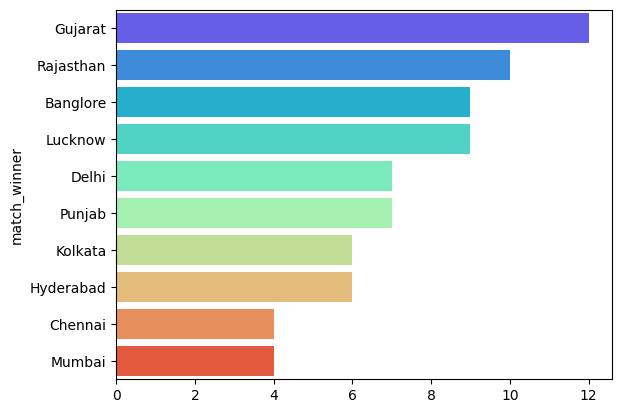

In [22]:
matchwins = df["match_winner"].value_counts()
# print(matchwins)
sns.barplot(x= matchwins.values ,y= matchwins.index, palette="rainbow")

Toss decision trends

<Axes: xlabel='toss_decision', ylabel='count'>

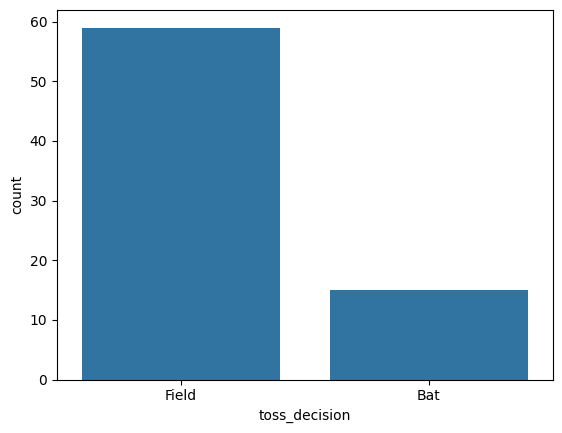

In [23]:
sns.countplot(x= df['toss_decision'])

Toss winner vs Match winner

In [32]:
count = df[df["toss_winner"] == df["match_winner"]]["match_id"].count()
percentage = (count*100) / df["match_id"].count()
print(percentage.round(2))

48.65


How do teams win:- Runs or Wickets

Text(0.5, 1.0, 'Won_by')

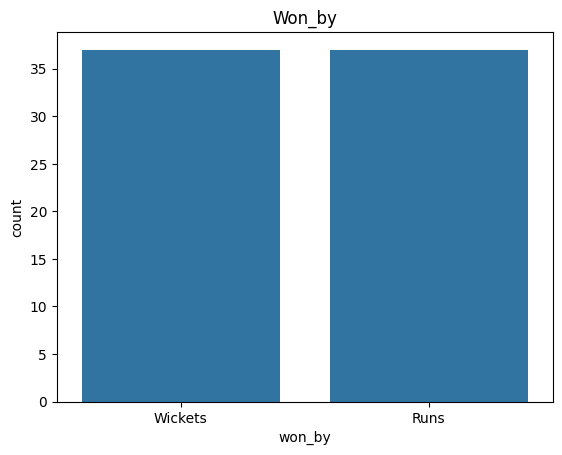

In [ ]:
sns.countplot(x=df["won_by"])
plt.title("Won_by")

# Key Player Performances

Most man of the Match awards 

<Axes: ylabel='player_of_the_match'>

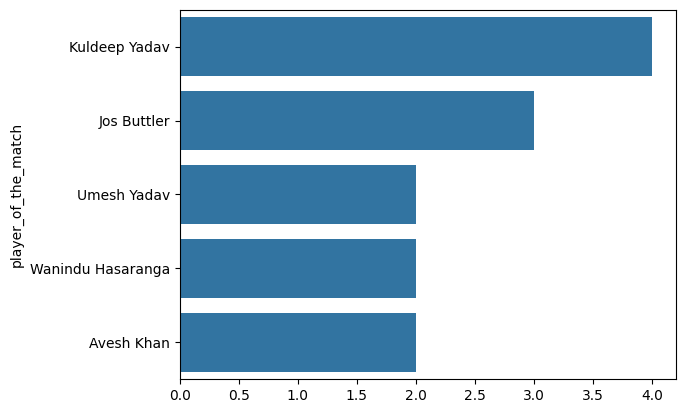

In [80]:
count = df["player_of_the_match"].value_counts().head(5)
sns.barplot(x=count.values ,y= count.index)
# count.idxmax()

Top Scorers

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64


<Axes: ylabel='top_scorer'>

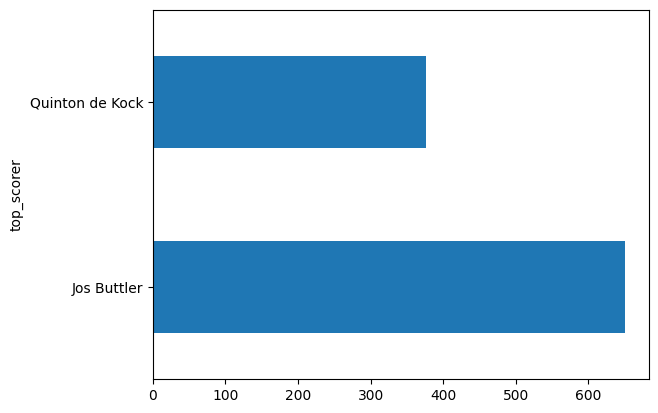

In [100]:
high = df.groupby("top_scorer")["highscore"].sum().sort_values(ascending= False).head(2)
print(high)
high.plot(kind= "barh")

10 Best Bowling Figures

<Axes: xlabel='best_bowling'>

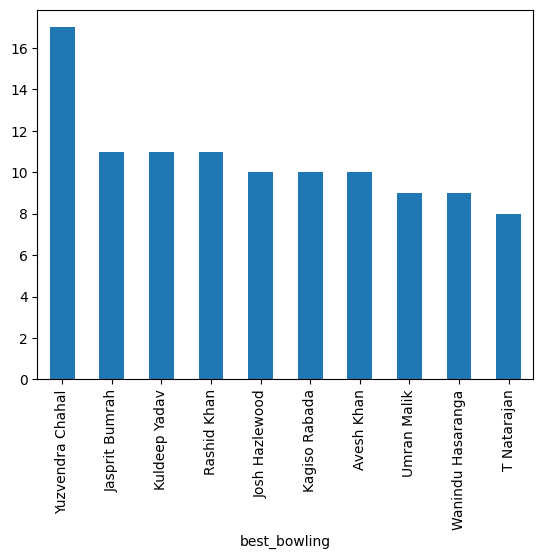

In [183]:
df["highest_wickets"] = df["best_bowling_figure"].apply(lambda x : x.split("--")[0]).astype(int)

top_bowlers = df.groupby("best_bowling")["highest_wickets"].sum().sort_values(ascending=False).head(10)

top_bowlers.plot(kind= "bar")



# Venue Analysis

Most matches played by Venue

<Axes: xlabel='venue'>

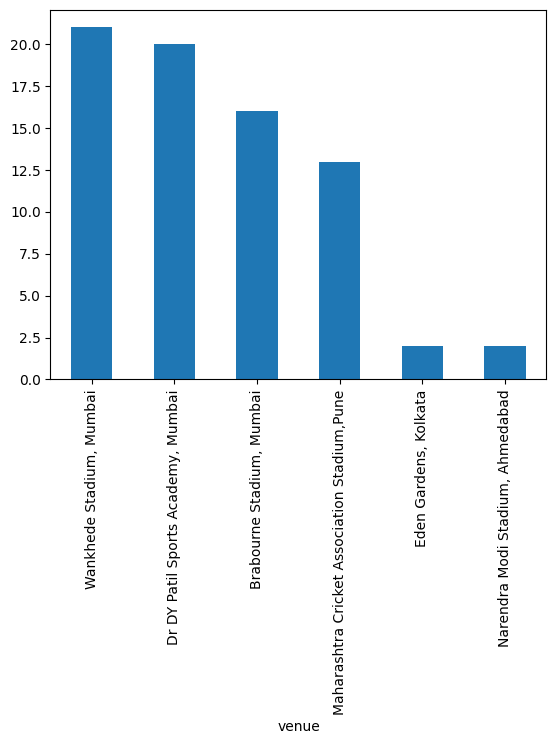

In [129]:
venue_count = df['venue'].value_counts()

venue_count.plot(kind= "bar")

## Custom Questions and Insights

Who won the highest margin by runs?

In [ ]:
df[df["won_by"] == "Runs"].sort_values(by= "margin",ascending= False).head(1)[["match_winner","margin"]]

,match_winner,margin
54,Chennai,91


Which Player had the Highest individual Score

In [170]:
df.sort_values(by= "highscore",ascending= False).head(1)[["top_scorer","highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140


Which Bowler had the Best Bowling Figures?

In [185]:
# df.sort_values(by= "highest_wickets",ascending=False).head(1)[['best_bowling_figure',"best_bowling"]]
df[df["highest_wickets"] == df["highest_wickets"].max()][['best_bowling_figure',"best_bowling"]]

,best_bowling_figure,best_bowling
29,5--40,Yuzvendra Chahal
39,5--25,Umran Malik
53,5--18,Wanindu Hasaranga
55,5--10,Jasprit Bumrah
